In [ ]:
# ==========================
# 1. Setup & Sentinel Hub Config (with auto path correction)
# ==========================
import os
from datetime import datetime, timedelta
from sentinelhub import SHConfig, BBox, CRS

# --- auto path correction so notebook runs anywhere ---
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("📁 Working directory:", os.getcwd())

# --- directory setup ---
os.makedirs("data/predictions", exist_ok=True)
os.makedirs("config", exist_ok=True)

# --- Mumbai AOI (Bounding box in WGS84) ---
AOI_NAME = "Mumbai"
AOI_BBOX = BBox(bbox=[72.77, 18.89, 73.10, 19.35], crs=CRS.WGS84)
AOI_RESOLUTION = 20  # start at 20 m; will downscale if > 2500 px

# --- Sentinel Hub credentials (replace with your real ones) ---
config = SHConfig()
config.sh_client_id = "2b590806-9858-4137-8ed6-3ffc52f8649f"
config.sh_client_secret = "TtZlqnzDwdPH9pnxfZtYZYRjx5esN3EF"
config.save("config/creds_sentinelhub.json")

# --- verify credentials ---
if not config.sh_client_id or not config.sh_client_secret:
    raise ValueError("Please set your Sentinel Hub client_id and client_secret above.")
else:
    print("✅ Sentinel Hub credentials configured.")

# --- date window for fetching (past 24 hours) ---
END_DATE = datetime.utcnow()
START_DATE = END_DATE - timedelta(days=1)
print(f"📅 Fetching Sentinel-1 data for {AOI_NAME} between {START_DATE.date()} and {END_DATE.date()}")


📁 Working directory: /Users/vainavilad/flood-mumbai
✅ Sentinel Hub credentials configured.
📅 Fetching Sentinel-1 data for Mumbai between 2025-10-23 and 2025-10-24


In [3]:
# ==========================
# 2. Fetch Sentinel-1 VV & VH data for Mumbai (auto-resize ≤ 2500 px)
# ==========================
from sentinelhub import (
    SentinelHubRequest, DataCollection, MimeType, bbox_to_dimensions
)
import numpy as np

# --- compute size at target resolution ---
size = bbox_to_dimensions(AOI_BBOX, resolution=AOI_RESOLUTION)
width, height = size
print(f"🛰️ Initial image size for {AOI_NAME}: {width} × {height} pixels")

# --- enforce Sentinel Hub 2500 px limit ---
MAX_DIM = 2500
if height > MAX_DIM or width > MAX_DIM:
    scale = min(MAX_DIM / height, MAX_DIM / width)
    size = (int(width * scale), int(height * scale))
    print(f"⚙️ Image resized to {size} to stay ≤ 2500 pixels (scale {scale:.2f})")

# --- define Sentinel-1 request ---
request = SentinelHubRequest(
    data_folder="data/raw_mumbai_latest",
    evalscript="""
        //VERSION=3
        function setup() {
            return {
                input: ["VV", "VH"],
                output: [{ id: "default", bands: 2, sampleType: "FLOAT32" }]
            };
        }
        function evaluatePixel(sample) {
            return [sample.VV, sample.VH];
        }
    """,
    input_data=[
        SentinelHubRequest.input_data(
            data_collection=DataCollection.SENTINEL1_IW,
            time_interval=(START_DATE.strftime("%Y-%m-%d"), END_DATE.strftime("%Y-%m-%d")),
            mosaicking_order="mostRecent"
        )
    ],
    responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
    bbox=AOI_BBOX,
    size=size,
    config=config
)

# --- execute request ---
try:
    data = request.get_data(save_data=True)
    print(f"✅ Downloaded {len(data)} Sentinel-1 image(s); saved to data/raw_mumbai_latest/")
except Exception as e:
    print("❌ Download failed:", e)

🛰️ Initial image size for Mumbai: 1766 × 2526 pixels
⚙️ Image resized to (1747, 2500) to stay ≤ 2500 pixels (scale 0.99)
✅ Downloaded 1 Sentinel-1 image(s); saved to data/raw_mumbai_latest/


📂 Using image: data/raw_mumbai_latest/cfbe3f5ee37f795e75c316e2e04a438c/response.tiff
📊 Loaded normalization stats: {'mean': [-11.281756708657582, -18.101943310824943], 'std': [4.945670508896773, 5.675061883943235]}
🛰️ Raw image shape: (2500, 1747, 2)
✅ Model loaded: models/unet_flood.keras
1/1 [==============================] - 0s 233ms/step
💾 Saved flood mask to data/predictions/flood_pred_20251024_1229.tif


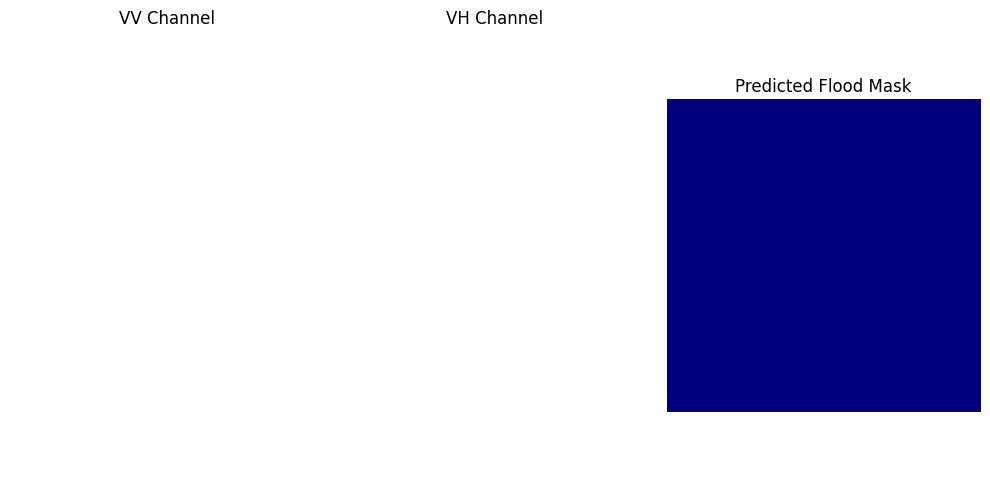

🌊 Flood pixel ratio = 0.000 → No Flood ✅


In [4]:
# ==========================
# 3. Preprocess & Predict Flood Mask (auto-detect subfolder)
# ==========================
import os, json, numpy as np, matplotlib.pyplot as plt, cv2, rasterio
from rasterio.enums import Resampling
from datetime import datetime
from tensorflow.keras.models import load_model

# --- paths ---
RAW_ROOT = "data/raw_mumbai_latest"
MODEL_PATH = "models/unet_flood.keras"
STATS_PATH = "models/global_stats.json"
PRED_DIR = "data/predictions"

# --- find actual response.tiff path ---
tiff_path = None
for root, _, files in os.walk(RAW_ROOT):
    for f in files:
        if f.lower().endswith("response.tiff"):
            tiff_path = os.path.join(root, f)
            break
if not tiff_path:
    raise FileNotFoundError("No response.tiff found under data/raw_mumbai_latest/")
print("📂 Using image:", tiff_path)

# --- load normalization stats ---
with open(STATS_PATH, "r") as f:
    stats = json.load(f)
gmean, gstd = stats["mean"], stats["std"]
print("📊 Loaded normalization stats:", stats)

# --- load Sentinel-1 VV/VH stack ---
with rasterio.open(tiff_path) as src:
    img = src.read(out_shape=(2, src.height, src.width),
                   resampling=Resampling.bilinear).astype(np.float32)
img = np.transpose(img, (1, 2, 0))
print("🛰️ Raw image shape:", img.shape)

# --- normalize ---
for c in range(2):
    img[..., c] = (img[..., c] - gmean[c]) / (gstd[c] + 1e-8)

# --- resize for U-Net ---
resized = cv2.resize(img, (256, 256), interpolation=cv2.INTER_LINEAR)
resized = np.expand_dims(resized, axis=0)

# --- load model ---
model = load_model(MODEL_PATH, compile=False)
print("✅ Model loaded:", MODEL_PATH)

# --- predict ---
pred = model.predict(resized)[0, :, :, 0]
pred_mask = (pred > 0.5).astype(np.uint8)

# --- save prediction ---
os.makedirs(PRED_DIR, exist_ok=True)
pred_path = os.path.join(PRED_DIR, f"flood_pred_{datetime.utcnow().strftime('%Y%m%d_%H%M')}.tif")

with rasterio.open(tiff_path) as src:
    profile = src.profile
profile.update(count=1, dtype=rasterio.uint8)
with rasterio.open(pred_path, "w", **profile) as dst:
    dst.write(pred_mask, 1)

print(f"💾 Saved flood mask to {pred_path}")

# --- visualize ---
plt.figure(figsize=(10,5))
plt.subplot(1,3,1); plt.imshow(img[...,0], cmap="gray"); plt.title("VV Channel"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(img[...,1], cmap="gray"); plt.title("VH Channel"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(pred_mask, cmap="jet"); plt.title("Predicted Flood Mask"); plt.axis("off")
plt.tight_layout(); plt.show()

# --- classify flood / no-flood ---
flood_ratio = np.sum(pred_mask) / pred_mask.size
threshold = 0.05
print(f"🌊 Flood pixel ratio = {flood_ratio:.3f} → {'Flood ⚠️' if flood_ratio>threshold else 'No Flood ✅'}")


In [5]:
# ==========================
# 4. Feature logging + simple alert (append CSV)
# ==========================
import os, glob, json, numpy as np, pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo
import rasterio

FEATURES_CSV = "data/features/features.csv"
ALERTS_LOG   = "data/features/alerts.log"
THRESHOLD    = 0.05  # flood pixel ratio threshold

os.makedirs(os.path.dirname(FEATURES_CSV), exist_ok=True)

# --- find latest prediction file and source tiff (if vars from Cell 3 don't exist) ---
def _latest_prediction_path():
    cands = sorted(glob.glob("data/predictions/flood_pred_*.tif"))
    return cands[-1] if cands else None

def _latest_raw_tiff_path():
    for root, _, files in os.walk("data/raw_mumbai_latest"):
        for f in files:
            if f.lower().endswith("response.tiff"):
                return os.path.join(root, f)
    return None

# Use existing variables from Cell 3 if present; otherwise load from disk
try:
    current_pred_mask = pred_mask  # from Cell 3
    current_pred_path = pred_path
    current_raw_path  = tiff_path
except NameError:
    current_pred_path = _latest_prediction_path()
    current_raw_path  = _latest_raw_tiff_path()
    if current_pred_path is None:
        raise FileNotFoundError("No prediction mask found in data/predictions/. Run Cell 3 first.")
    # Load mask from GeoTIFF (as uint8 0/1)
    with rasterio.open(current_pred_path) as ds:
        arr = ds.read(1)
    current_pred_mask = (arr > 0).astype(np.uint8)

# --- compute features for this run ---
flooded_pct = float(np.mean(current_pred_mask))  # ratio in [0,1]
decision = "FLOOD" if flooded_pct > THRESHOLD else "NO_FLOOD"

# --- load previous features (if any) to compute change ---
prev_flooded_pct = None
if os.path.exists(FEATURES_CSV):
    try:
        df_prev = pd.read_csv(FEATURES_CSV)
        if len(df_prev) > 0:
            prev_flooded_pct = float(df_prev.iloc[-1]["flooded_pct"])
    except Exception:
        prev_flooded_pct = None

flood_change = (flooded_pct - prev_flooded_pct) if prev_flooded_pct is not None else None

# --- timestamps ---
ts_utc = datetime.utcnow().replace(tzinfo=ZoneInfo("UTC"))
ts_ist = datetime.now(ZoneInfo("Asia/Kolkata"))

# --- assemble row ---
row = {
    "timestamp_utc": ts_utc.isoformat(timespec="seconds"),
    "timestamp_ist": ts_ist.isoformat(timespec="seconds"),
    "aoi": "Mumbai",
    "flooded_pct": round(flooded_pct, 6),
    "flood_change": round(flood_change, 6) if flood_change is not None else "",
    "threshold": THRESHOLD,
    "decision": decision,
    "raw_tiff": current_raw_path if current_raw_path else "",
    "pred_tiff": current_pred_path
}

# --- append to CSV ---
if os.path.exists(FEATURES_CSV):
    df = pd.read_csv(FEATURES_CSV)
    df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
else:
    df = pd.DataFrame([row])
df.to_csv(FEATURES_CSV, index=False)

# --- simple alert log if flood ---
if decision == "FLOOD":
    with open(ALERTS_LOG, "a") as f:
        f.write(f"[{row['timestamp_ist']}] FLOOD ALERT: flooded_pct={row['flooded_pct']}, "
                f"change={row['flood_change']}, pred={row['pred_tiff']}\n")

print("📝 Features appended to:", FEATURES_CSV)
print(f"🌊 flooded_pct={row['flooded_pct']:.3f}  change={row['flood_change']}  → {decision}")
print("🔗 Prediction:", current_pred_path)
print("🔗 Source S1:", current_raw_path)
if decision == "FLOOD":
    print("⚠️ Alert written to:", ALERTS_LOG)

# --- (Optional) show the last few rows for quick sanity check ---
try:
    display(df.tail(5))
except NameError:
    print(df.tail(5))

from whatsapp_alert import send_whatsapp_alert

if decision == "FLOOD":
    alert_msg = f"⚠️ FLOOD ALERT for Mumbai!\nFlooded area: {row['flooded_pct']*100:.2f}%\nTime: {row['timestamp_ist']}"
    send_whatsapp_alert(alert_msg)

📝 Features appended to: data/features/features.csv
🌊 flooded_pct=0.000  change=  → NO_FLOOD
🔗 Prediction: data/predictions/flood_pred_20251024_1229.tif
🔗 Source S1: data/raw_mumbai_latest/cfbe3f5ee37f795e75c316e2e04a438c/response.tiff


,timestamp_utc,timestamp_ist,aoi,flooded_pct,flood_change,threshold,decision,raw_tiff,pred_tiff
0,2025-10-24T12:30:01+00:00,2025-10-24T18:00:01+05:30,Mumbai,0.0,,0.05,NO_FLOOD,data/raw_mumbai_latest/cfbe3f5ee37f795e75c316e...,data/predictions/flood_pred_20251024_1229.tif


In [4]:
# ==========================
# 5. Create auto-runner script (run_pipeline.py)
# ==========================
import os

script_content = """#!/usr/bin/env python3
import os, sys, time
from datetime import datetime
import subprocess

base = os.path.dirname(os.path.abspath(__file__))
nb_path = os.path.join(base, "notebooks", "01_fetch_S1_Mumbai.ipynb")

# Sequentially run cells 1–3 via papermill
print("🚀 Running flood pipeline at", datetime.utcnow().isoformat())
cmd = [
    sys.executable, "-m", "papermill",
    nb_path,
    os.path.join(base, "notebooks", "runs", f"run_{datetime.utcnow().strftime('%Y%m%d_%H%M')}.ipynb")
]
os.makedirs(os.path.join(base, "notebooks", "runs"), exist_ok=True)
subprocess.run(cmd, check=False)
print("✅ Pipeline finished.")
"""

runner_path = "run_pipeline.py"
with open(runner_path, "w") as f:
    f.write(script_content)
os.chmod(runner_path, 0o755)
print(f"✅ Created {runner_path}. You can run it anytime with:  python {runner_path}")

✅ Created run_pipeline.py. You can run it anytime with:  python run_pipeline.py
